# Create networks and calcualte indexes

## Create networks for each location

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import itertools
import sys

from collections import defaultdict
import math

try:
    import igraph as ig
    import leidenalg
except ImportError:
    print("Error: Required packages are missing.")
    print("Please run: pip install igraph leidenalg")
    sys.exit(1)

## Transforming the 6 dss to dfs

In [2]:
ds_hu = xr.open_dataset("/Volumes/T7/Data/Carpathian_basin/CB_clipped_nc/hu_ens_mean_0.1deg_reg_v31.0e_clipped.nc")
ds_qq = xr.open_dataset("/Volumes/T7/Data/Carpathian_basin/CB_clipped_nc/qq_ens_mean_0.1deg_reg_v31.0e_clipped.nc")
ds_rr = xr.open_dataset("/Volumes/T7/Data/Carpathian_basin/CB_clipped_nc/rr_ens_mean_0.1deg_reg_v31.0e_clipped.nc")
ds_tg = xr.open_dataset("/Volumes/T7/Data/Carpathian_basin/CB_clipped_nc/tg_ens_mean_0.1deg_reg_v31.0e_clipped.nc")
ds_tn = xr.open_dataset("/Volumes/T7/Data/Carpathian_basin/CB_clipped_nc/tn_ens_mean_0.1deg_reg_v31.0e_clipped.nc")
ds_tx = xr.open_dataset("/Volumes/T7/Data/Carpathian_basin/CB_clipped_nc/tx_ens_mean_0.1deg_reg_v31.0e_clipped.nc")

print(f"Input .nc files read successfully")

Input .nc files read successfully


In [3]:
def extract_eobs_timeseries(ds, var_name, lat, lon, start=None, end=None):
    """
    Extract a time series from an E-OBS dataset at a given location
    and within a selected time period.

    Parameters
    ----------
    ds : xarray.Dataset
        The loaded E-OBS dataset.
    var_name : str
        Name of the variable to extract, e.g. "tg".
    lat : float
        Latitude of the desired location.
    lon : float
        Longitude of the desired location.
    start : str or None
        Start date in format 'YYYY-MM-DD' (e.g. '1960-01-01').
        If None, no lower time bound is applied.
    end : str or None
        End date in format 'YYYY-MM-DD'.
        If None, no upper time bound is applied.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing time, lat, lon, and the variable values.
    """

    # Select time range if provided
    if start or end:
        ds = ds.sel(time=slice(start, end))

    # Extract nearest grid point for the variable
    ts = ds[var_name].sel(latitude=lat, longitude=lon, method="nearest")

    # Convert to DataFrame
    df = ts.to_dataframe().reset_index()

    return df

In [4]:
def get_minimum_necessary_df(large_df, variable):
    df = pd.DataFrame()

    df["time"] = large_df["time"]
    df[variable] = large_df[variable]

    return df

In [5]:
def get_df_from_ds_for_variable(ds, var_name, lat, lon, start="1961-01-01", end=None):

    whole_df = extract_eobs_timeseries(
        ds,
        var_name=var_name,
        lat=lat,
        lon=lon,
        start=start,
        end=end
    )

    # print(f"got whole df {whole_df}")

    df = get_minimum_necessary_df(whole_df, var_name)

    return df

In [6]:
def get_all_component_dfs(lat, lon):
    df_hu = get_df_from_ds_for_variable(ds_hu, "hu", lat, lon)
    df_qq = get_df_from_ds_for_variable(ds_qq, "qq", lat, lon)
    df_rr = get_df_from_ds_for_variable(ds_rr, "rr", lat, lon)
    df_tg = get_df_from_ds_for_variable(ds_tg, "tg", lat, lon)
    df_tn = get_df_from_ds_for_variable(ds_tn, "tn", lat, lon)
    df_tx = get_df_from_ds_for_variable(ds_tx, "tx", lat, lon)

    return df_hu, df_qq, df_rr, df_tg, df_tn, df_tx

## Creating the networks

In [7]:
import json
import os

import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform

# from networks.utils.get_rich_monthly_nodes import get_rich_monthly_nodes
# from networks.utils.prune_to_average_degree import prune_to_average_degree

In [8]:
# get rich monthly nodes

def get_rich_monthly_nodes(lat, lon, start, end, target_month=0):

    start_date = pd.to_datetime(start)
    end_date = pd.to_datetime(end)

    hu_df, qq_df, rr_df, tg_df, tn_df, tx_df = get_all_component_dfs(lat, lon)

    # Convert 'time' column to datetime objects
    tg_df['time'] = pd.to_datetime(tg_df['time'])
    tn_df['time'] = pd.to_datetime(tn_df['time'])
    tx_df['time'] = pd.to_datetime(tx_df['time'])
    rr_df['time'] = pd.to_datetime(rr_df['time'])
    qq_df['time'] = pd.to_datetime(qq_df['time'])
    hu_df['time'] = pd.to_datetime(hu_df['time'])

    # Set 'time' as the index
    tg_df.set_index('time', inplace=True)
    tn_df.set_index('time', inplace=True)
    tx_df.set_index('time', inplace=True)
    rr_df.set_index('time', inplace=True)
    qq_df.set_index('time', inplace=True)
    hu_df.set_index('time', inplace=True)

    # Merge the dataframes
    df = tg_df.join(tn_df).join(tx_df).join(rr_df).join(qq_df).join(hu_df)

    # Resample the data by month and aggregate
    monthly_nodes = {}
    for name, group in df.groupby(pd.Grouper(freq='ME')):

        if target_month != 0 and name.month != target_month:
            continue

        if name < start_date or name.to_period('M') > end_date.to_period('M'):
            continue
        

        month_str = name.strftime('%Y-%m')
        
        # Calculate the mean of tn and tx for the month
        mean_tn = group['tn'].mean()
        mean_tx = group['tx'].mean()
        mean_tg = group['tg'].mean()
        rr_sum = group['rr'].sum()
        mean_qq = group['qq'].mean()
        mean_hu = group['hu'].mean()


        metrics = [mean_tn, mean_tx, mean_tg, rr_sum, mean_qq, mean_hu]
        if any(pd.isna(m) for m in metrics):
            # print(f"Skipping month {month_str} due to missing data.")
            continue
        
        monthly_nodes[month_str] = {
            'mean_tn': mean_tn,
            'mean_tx': mean_tx,
            'mean_tg': mean_tg,
            'rr_sum': rr_sum,
            'mean_qq': mean_qq,
            'mean_hu': mean_hu
        }

    return monthly_nodes


In [9]:
# prune to average degree

def prune_to_average_degree(graph, target_avg_degree=64, weight_attr='weight'):
    """
    Reads a GraphML file and removes the weakest links until the 
    average degree drops to the target value.
    
    Args:
        graphml_path (str): Path to the .graphml file.
        target_avg_degree (float): The desired average degree (default 64).
        weight_attr (str): The key in the GraphML used for edge weights.
        
    Returns:
        nx.Graph: The pruned graph object.
    """
    # 1. Read the graph
    # Force undirected if your logic implies simple connectivity. 
    # If your graph is directed, remove force_multigraph/multigraph checks as needed.
    # G = nx.read_graphml(graphml_path)
    G = graph
    
    # 2. Basic Stats
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    
    if num_nodes == 0:
        print("Graph is empty.")
        return G

    # 3. Determine target number of edges
    # Formula for Avg Degree (k) in Undirected Graph: k = 2E / N
    # Therefore, Target Edges (E) = (k * N) / 2
    if G.is_directed():
        # For directed, usually Avg Degree = E / N
        target_num_edges = int(target_avg_degree * num_nodes)
    else:
        target_num_edges = int((target_avg_degree * num_nodes) / 2)
        
    edges_to_remove_count = num_edges - target_num_edges

    # 4. Check if pruning is actually needed
    if edges_to_remove_count <= 0:
        current_degree = (2 * num_edges / num_nodes) if not G.is_directed() else (num_edges / num_nodes)
        # print(f"No pruning needed. Current average degree ({current_degree:.2f}) is already <= {target_avg_degree}.")
        return G

    # print(f"Pruning {edges_to_remove_count} edges to reach average degree of {target_avg_degree}...")

    # 5. Get all edges with data, sort by weight (ascending), and slice
    # This is O(E log E), much faster than re-calculating degrees inside a loop
    all_edges = sorted(G.edges(data=True), key=lambda x: x[2].get(weight_attr, 0))
    
    # Identify the weakest edges
    weakest_links = all_edges[:edges_to_remove_count]
    
    # 6. Remove the edges
    # We extract just the (u, v) tuples for removal
    G.remove_edges_from([(u, v) for u, v, d in weakest_links])
    
    # Verification
    final_edges = G.number_of_edges()
    final_avg = (2 * final_edges / num_nodes) if not G.is_directed() else (final_edges / num_nodes)
    # print(f"Finished. Final Average Degree: {final_avg:.2f}")
    
    return G

# --- Usage Example ---
# G = prune_to_average_degree("my_network.graphml", target_avg_degree=64, weight_attr='weight')
# nx.write_graphml(G, "pruned_network.graphml")

In [10]:
def calculate_pca_similarity_matrix(monthly_nodes, n_components=2):
    """
    Illeszt egy PCA modellt és kiszámítja a hasonlósági mátrixot.
    Visszaadja a mátrixot, a hónapokat, a súlyokat és az illesztett modelleket.
    
    Argumentumok:
    monthly_nodes (dict): Kulcsok a hónapok ('YYYY-MM'), értékek a havi klímaadatok.
    n_components (int): A PCA-hoz használt főkomponensek száma.
    
    Visszatérési érték:
    tuple: (similarity_matrix, months, component_weights, scaler, pca, d_min, d_max)
    """
    months = list(monthly_nodes.keys())
    sample_month_data = monthly_nodes[months[0]]
    # print(f"got sample_month_data: {sample_month_data}")
    feature_keys = [key for key, value in sample_month_data.items() if isinstance(value, (int, float, np.number))]
    
    # print(f'Felhasznált változók a PCA-hoz: {feature_keys}')
    
    X = np.array([[monthly_nodes[month][key] for key in feature_keys] for month in months])
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X_scaled)
    
    # print(f'Magyarázott variancia aránya a komponensekkel: {pca.explained_variance_ratio_}')
    
    # Komponens súlyok kinyerése
    component_weights = {}
    for i, component in enumerate(pca.components_):
        component_weights[f'component_{i+1}'] = dict(zip(feature_keys, component))
    
    distances = pdist(scores, metric='euclidean')
    
    d_min = distances.min() if distances.size > 0 else 0.0
    d_max = distances.max() if distances.size > 0 else 1.0
    
    if d_max - d_min > 0:
        scaled_distances = (distances - d_min) / (d_max - d_min)
    else:
        scaled_distances = np.zeros_like(distances)
    
    scaled_distances = np.clip(scaled_distances, 0.0, 1.0)
    similarity_matrix = 1 - squareform(scaled_distances)
    
    return similarity_matrix, months, component_weights, scaler, pca, d_min, d_max

def calculate_similarity_with_existing_pca(monthly_nodes, scaler, pca, d_min=None, d_max=None):
    """
    Kiszámítja a hasonlósági mátrixot egy előre illesztett PCA modell használatával.
    """
    months = list(monthly_nodes.keys())
    if not months:
        return np.array([]), []
        
    sample_month_data = monthly_nodes[months[0]]
    feature_keys = [key for key, value in sample_month_data.items() if isinstance(value, (int, float, np.number))]
    
    X = np.array([[monthly_nodes[month][key] for key in feature_keys] for month in months])
    
    X_scaled = scaler.transform(X)
    scores = pca.transform(X_scaled)
    
    distances = pdist(scores, metric='euclidean')
    
    c_min = distances.min() if d_min is None else d_min
    c_max = distances.max() if d_max is None else d_max
    
    if c_max - c_min > 0:
        scaled_distances = (distances - c_min) / (c_max - c_min)
    else:
        scaled_distances = np.zeros_like(distances)
    
    scaled_distances = np.clip(scaled_distances, 0.0, 1.0)
    similarity_matrix = 1 - squareform(scaled_distances)
    
    return similarity_matrix, months

In [11]:
def create_networks_withs_shared_pca(lat, lon, target_avg_degree_factor=3):
    # threshold_json_filename = 'network_rich_thresholds.json'
    # weights_json_filename = 'pca_component_weights.json'
    
    # if os.path.exists(threshold_json_filename):
    #     with open(threshold_json_filename, 'r') as f: threshold_store = json.load(f)
    # else: threshold_store = {}
        
    # if os.path.exists(weights_json_filename):
    #     with open(weights_json_filename, 'r') as f: weights_store = json.load(f)
    # else: weights_store = {}

    # 1. Hozzon létre egy közös PCA-teret a teljes időszak (1961-2024) adataiból
    full_period_nodes = get_rich_monthly_nodes(lat, lon, '1961-01', '2024-12')
    
    if not full_period_nodes:
        print(f"FIGYELMEZTETÉS: Nincs adat a teljes időszakra a(z) {lat} - {lon} számára. A város kihagyása.")
        return None, None, None

    # Illesszen PCA-t a teljes adatsorra, hogy megkapja a közös tér modelleket és súlyokat
    full_sim_matrix, full_months, shared_weights, shared_scaler, shared_pca, d_min, d_max = calculate_pca_similarity_matrix(full_period_nodes)
    
    # # Tárolja a közös súlyokat
    # weights_key = f'{city}_shared_1961-2024'
    # weights_store[weights_key] = shared_weights
    # with open(weights_json_filename, 'w') as f: json.dump(weights_store, f, indent=4)
    # print(f'PCA súlyok mentve a(z) {city} számára (közös): {weights_key}')

    # 2. Definiálja az időszakokat és dolgozza fel mindegyiket
    periods_to_process = [
        ('1961-01', '1990-12'), # korai
        ('1995-01', '2024-12'), # késői
        ('1961-01', '2024-12')  # teljes
    ]

    full_period_result_graph = None
    early_period_result_graph = None
    late_period_result_graph = None

    for start, end in periods_to_process:
        # print(f'--- Hálózat építése: {city} : {start} - {end} ---')

        if start == '1961-01' and end == '2024-12':
            # Ez a teljes időszak, már rendelkezünk a mátrixszal
            similarity_matrix, months = full_sim_matrix, full_months
            period_nodes = full_period_nodes
        else:
            period_nodes = get_rich_monthly_nodes(lat, lon, start, end)
            if not period_nodes:
                print(f"FIGYELMEZTETÉS: Nincs adat a(z) {start}-{end} időszakra a(z) {lat} - {lon} számára. Kihagyás.")
                continue
            # Használja a közös PCA-teret a hasonlóság kiszámításához
            similarity_matrix, months = calculate_similarity_with_existing_pca(period_nodes, shared_scaler, shared_pca, d_min, d_max)

        # --- A többi a hálózatépítés, metszés és mentés ---
        # json_key = f'{city}_{start}_{end}'
        
        G = nx.Graph()
        for month, data in period_nodes.items():
            G.add_node(month, **data)

        for i, j in itertools.combinations(range(len(months)), 2):
            score = similarity_matrix[i, j]
            if score > 0:
                G.add_edge(months[i], months[j], weight=score)

        # print(f'Kezdeti hálózat - Csomópontok: {G.number_of_nodes()}, Élek: {G.number_of_edges()}')

        num_years = int(end[:4]) - int(start[:4]) + 1
        target_avg_degree = num_years * target_avg_degree_factor - 1
        
        pruned_graph = prune_to_average_degree(G, target_avg_degree=target_avg_degree)

        if pruned_graph.number_of_edges() > 0:
            edge_weights = [d['weight'] for _, _, d in pruned_graph.edges(data=True)]
            final_threshold = float(min(edge_weights))
        else:
            final_threshold = 1.0
        
        # threshold_store[json_key] = final_threshold
        # with open(threshold_json_filename, 'w') as f: json.dump(threshold_store, f, indent=4)
        # print(f'Küszöbérték ({final_threshold:.4f}) mentve: {json_key}')
        
        for node, data in pruned_graph.nodes(data=True):
            try:
                year, month = str(node).split('-')
                data['year'] = int(year)
                data['month'] = int(month)
            except ValueError:
                data['year'] = None
                data['month'] = None

        if start == '1961-01':
            if end == '2024-12':
                full_period_result_graph = pruned_graph
            else:
                early_period_result_graph = pruned_graph
        else:
            late_period_result_graph = pruned_graph
        
        
    return early_period_result_graph, late_period_result_graph, full_period_result_graph

# Calculating the indexes

## Percolation index

In [12]:
def run_percolation(G, thresholds):
    """
    Runs percolation by incrementally removing edges below the given thresholds.
    Returns the Largest Connected Component (LCC) fractions and the critical 
    threshold (the split point where the graph fragments the most).
    """
    total_nodes = G.number_of_nodes()
    if total_nodes == 0:
        return None
        
    lcc_fractions = []
    
    for threshold in thresholds:
        filtered_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('weight', 1.0) >= threshold]
        
        H = nx.Graph()
        H.add_nodes_from(G.nodes())
        H.add_edges_from(filtered_edges)
        
        if H.number_of_edges() == 0:
            lcc_fractions.append(1.0 / total_nodes)
        else:
            largest_cc = max(nx.connected_components(H), key=len)
            lcc_fractions.append(len(largest_cc) / total_nodes)
            
    # Find critical threshold (steepest drop in LCC fraction implies graph splitting)
    drops = -np.diff(lcc_fractions)
    if len(drops) > 0 and np.max(drops) > 0:
        max_drop_idx = np.argmax(drops)
        # The threshold where the massive drop begins
        critical_threshold = float(thresholds[max_drop_idx])
    else:
        critical_threshold = None
        
    return {
        "lcc_fractions": lcc_fractions,
        "critical_threshold": critical_threshold
    }

In [13]:
def get_percolation_index(early, late):

    NUM_STEPS = 50

    G_early = early
    G_late = late
    
    # Combine edge weights from both graphs to get a common range for the threshold X-axis
    early_weights = [d.get('weight', 1.0) for u, v, d in G_early.edges(data=True)]
    late_weights = [d.get('weight', 1.0) for u, v, d in G_late.edges(data=True)]
    all_weights = early_weights + late_weights
    
    if not all_weights:
        print(f"  - WARNING: No edges found. Skipping.")
        return None
        
    min_w, max_w = min(all_weights), max(all_weights)
    thresholds = np.linspace(min_w, max_w, NUM_STEPS)
    
    # print("  - Simulating early period...")
    early_res = run_percolation(G_early, thresholds)
    
    # print("  - Simulating late period...")
    late_res = run_percolation(G_late, thresholds)

    early_threshold = early_res['critical_threshold']
    late_threshold = late_res['critical_threshold']

    # Calculate the index if both thresholds exist
    if early_threshold is not None and late_threshold is not None:
        # A positive index means the graph breaks apart at a higher threshold in the late period
        perc_index = late_threshold - early_threshold
        
        return perc_index
    
    print(f"No threshold found for split for early or late period")
    return None

## Community fragmentation index

In [14]:
def convert_nx_to_igraph(G):
    """
    Safely converts a NetworkX graph to an igraph Graph,
    preserving node names and edge weights.
    """
    node_names = list(G.nodes())
    g_ig = ig.Graph(directed=G.is_directed())
    g_ig.add_vertices(len(node_names))
    g_ig.vs['name'] = node_names
    
    name_to_idx = {name: i for i, name in enumerate(node_names)}
    edges = list(G.edges(data=True))
    ig_edges = [(name_to_idx[u], name_to_idx[v]) for u, v, d in edges]
    g_ig.add_edges(ig_edges)
    
    # Preserve weights if they exist
    if edges and 'weight' in edges[0][2]:
        weights = [d.get('weight', 1.0) for u, v, d in edges]
        g_ig.es['weight'] = weights
        
    return g_ig

def detect_communities(g_ig, resolution=1.0):
    """
    Runs the Leiden algorithm on an igraph object.
    Returns a dictionary mapping node names to their community ID.
    """
    weights = g_ig.es['weight'] if 'weight' in g_ig.edge_attributes() else None
    
    partition = leidenalg.find_partition(
        g_ig, 
        leidenalg.RBConfigurationVertexPartition,
        weights=weights,
        resolution_parameter=resolution,
        seed=42  # Adding a fixed seed for completely deterministic results
    )
    
    node_to_comm = {}
    for idx, cluster in enumerate(partition):
        for node_index in cluster:
            node_name = g_ig.vs[node_index]['name']
            node_to_comm[node_name] = idx
            
    return node_to_comm

def calculate_shannon_entropy(counts):
    """
    Calculates Shannon Entropy for the community distribution.
    Returns both the raw entropy and normalized entropy [0, 1].
    """
    total = sum(counts.values())
    if total == 0:
        return 0.0, 0.0
    
    entropy = 0.0
    for count in counts.values():
        p = count / total
        if p > 0:
            entropy -= p * math.log(p)
            
    max_entropy = math.log(total) if total > 1 else 1.0
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0.0
    
    return entropy, normalized_entropy

def get_graph_fragmentation(G):
    if G.number_of_nodes() == 0:
        return {}
        
    g_ig = convert_nx_to_igraph(G)
    node_to_comm = detect_communities(g_ig, resolution=1.0)
    
    total_graph_comms = len(set(node_to_comm.values()))
    # print(f"    - Detected {total_graph_comms} total communities in the graph.")
    
    month_community_counts = defaultdict(lambda: defaultdict(int))
    month_total_nodes = defaultdict(int)
    
    for node_name, comm_id in node_to_comm.items():
        try:
            # Node names are in the format "YYYY-MM"
            year, month = node_name.split('-')
            month_community_counts[month][comm_id] += 1
            month_total_nodes[month] += 1
        except ValueError:
            continue
            
    fragmentation = {}
    for month in sorted(month_community_counts.keys()):
        counts = month_community_counts[month]
        
        entropy, normalized_entropy = calculate_shannon_entropy(counts)
        
        total = month_total_nodes[month]
        simpson = 1.0 - sum((count / total) ** 2 for count in counts.values()) if total > 0 else 0.0
        
        fragmentation[month] = {
            "num_unique_communities": len(counts),
            "shannon_entropy": entropy,
            "normalized_entropy": normalized_entropy,
            "simpson_index": simpson,
            "community_distribution": counts
        }
        
    return fragmentation

def safe_ratio(late_val, early_val, eps=1e-3):
    if early_val == 0 and late_val == 0:
        return 1.0
    if early_val == 0:
        return late_val / eps
    return late_val / early_val

In [15]:
def get_community_fragmentation_index(early, late):
    G_early = early
    G_late = late
    
    early_frag = get_graph_fragmentation(G_early)
    late_frag = get_graph_fragmentation(G_late)
    
    location_results = {}
    for m in range(1, 13):
        month = f"{m:02d}"
        e_data = early_frag.get(month)
        l_data = late_frag.get(month)
        
        if not e_data and not l_data:
            continue
            
        ratio = {}
        if e_data and l_data:
            ratio = {
                "num_unique_communities": safe_ratio(l_data["num_unique_communities"], e_data["num_unique_communities"]),
                "shannon_entropy": safe_ratio(l_data["shannon_entropy"], e_data["shannon_entropy"]),
                "normalized_entropy": safe_ratio(l_data["normalized_entropy"], e_data["normalized_entropy"]),
                "simpson_index": safe_ratio(l_data["simpson_index"], e_data["simpson_index"])
            }
            
        location_results[month] = {
            "early": e_data,
            "late": l_data,
            "ratio_late_to_early": ratio
        }

    return location_results

## Degree distribution fragmentation

In [16]:
def get_close_months(month):
    """Returns the set of months considered 'close' (previous, current, next)."""
    prev_m = 12 if month == 1 else month - 1
    next_m = 1 if month == 12 else month + 1
    return {prev_m, month, next_m}

def process_graph(G):
    """
    Calculates the accumulated weighted and unweighted degrees for 'all months' 
    and 'close months' for each month of the year (1-12).
    """
    stats = {f"{m:02d}": {'unw_all': 0, 'unw_close': 0, 'w_all': 0.0, 'w_close': 0.0} for m in range(1, 13)}
    
    for node in G.nodes():
        try:
            month = int(node.split('-')[1])
        except (IndexError, ValueError):
            continue
            
        month_str = f"{month:02d}"
        close_months = get_close_months(month)
        
        # All neighbors
        unw_all = G.degree(node)
        w_all = G.degree(node, weight='weight')
        
        # Close neighbors
        unw_close = 0
        w_close = 0.0
        
        for neighbor in G.neighbors(node):
            try:
                n_month = int(neighbor.split('-')[1])
            except (IndexError, ValueError):
                continue
                
            if n_month in close_months:
                unw_close += 1
                w_close += G[node][neighbor].get('weight', 1.0)
                
        stats[month_str]['unw_all'] += unw_all
        stats[month_str]['unw_close'] += unw_close
        stats[month_str]['w_all'] += w_all
        stats[month_str]['w_close'] += w_close
        
    return stats

In [17]:
def get_degree_distribution_fragmentation(early, late):
    G_early = early
    G_late = late
    
    early_stats = process_graph(G_early)
    late_stats = process_graph(G_late)
    
    location_results = {}
    
    for m in range(1, 13):
        month_str = f"{m:02d}"
        e_stat = early_stats[month_str]
        l_stat = late_stats[month_str]
        
        # Calculate Early indices (close / all)
        e_unw_index = safe_ratio(e_stat['unw_close'], e_stat['unw_all'])
        e_w_index = safe_ratio(e_stat['w_close'], e_stat['w_all'])
        
        # Calculate Late indices (close / all)
        l_unw_index = safe_ratio(l_stat['unw_close'], l_stat['unw_all'])
        l_w_index = safe_ratio(l_stat['w_close'], l_stat['w_all'])
        
        location_results[month_str] = {
            "unweighted": {
                "early_index": e_unw_index,
                "late_index": l_unw_index,
                "ratio_late_to_early": safe_ratio(l_unw_index, e_unw_index)
            },
            "weighted": {
                "early_index": e_w_index,
                "late_index": l_w_index,
                "ratio_late_to_early": safe_ratio(l_w_index, e_w_index)
            }
        }

    return location_results

In [18]:
# # This creates an iterator of all (lat, lon) combinations
# grid_points = itertools.product(ds_hu['latitude'].values, ds_hu['longitude'].values)

# total_combinations = len(ds_hu['latitude'].values) * len(ds_hu['longitude'].values)
# print(f"num of coordinates: {total_combinations}")

# # lat = 45.84986054256413
# # lon = 23.24986029797654

# for lat, lon in grid_points:
#     print(f"Processing lat: {lat}, lon: {lon}")

#     early_network, late_network, full_network = create_networks_withs_shared_pca(lat, lon)
#     if early_network is not None and late_network is not None and full_network is not None:
#         print(f"Created early, late and full networks for {lat} - {lon}")
#         # print(f"early {early_network}\nlate {late_network}\n full {full_network}")

#         percolation_index = get_percolation_index(early_network, late_network)
#         print(f"Percolation index: {percolation_index}")

#         community_fragmentation = get_community_fragmentation_index(early_network, late_network)
#         # print(f"Community Fragmentation index: {community_fragmentation}")

#         for m in range(1, 13):
#             month_str = f"{m:02d}"

#             print(f"\tMonth: {month_str}\n")

#             early = community_fragmentation[month_str]["early"]
#             late = community_fragmentation[month_str]["late"]
#             ratio = community_fragmentation[month_str]["ratio_late_to_early"]

#             print(f"\t\tEarly:\n\t\t\tnum_unique_communitites: {early['num_unique_communities']}\n\t\t\tshannon_entropy: {early['shannon_entropy']}\n\t\t\tnormalized_entropy: {early['normalized_entropy']}\n\t\t\tsimpson_index: {early['simpson_index']}\n\n")

#             print(f"\t\tLate:\n\t\t\tnum_unique_communitites: {late['num_unique_communities']}\n\t\t\tshannon_entropy: {late['shannon_entropy']}\n\t\t\tnormalized_entropy: {late['normalized_entropy']}\n\t\t\tsimpson_index: {late['simpson_index']}\n\n")

#             print(f"\t\tRatio:\n\t\t\tnum_unique_communitites: {ratio['num_unique_communities']}\n\t\t\tshannon_entropy: {ratio['shannon_entropy']}\n\t\t\tnormalized_entropy: {ratio['normalized_entropy']}\n\t\t\tsimpson_index: {ratio['simpson_index']}\n\n")

#             print("\n")

#             # "num_unique_communities": len(counts),
#             # "shannon_entropy": entropy,
#             # "normalized_entropy": normalized_entropy,
#             # "simpson_index": simpson,

#         degree_distribution_fragmentation = get_degree_distribution_fragmentation(early_network, late_network)
#         # print(f"Degree Distribution Fragmentation index: {community_fragmentation}")

#         for m in range(1, 13):
#             month_str = f"{m:02d}"

#             unweighted = degree_distribution_fragmentation[month_str]["unweighted"]
#             weighted = degree_distribution_fragmentation[month_str]["weighted"]

#             print(f"\tMonth: {month_str}\n")

#             print(f"\t\tUnweighted:\n")

#             unw_early = unweighted["early_index"]
#             unw_late = unweighted["late_index"]
#             unw_ratio = unweighted["ratio_late_to_early"]

#             print(f"\t\t\tEarly: {unw_early}\n\t\t\tLate: {unw_late}\n\t\t\tRatio: {unw_ratio}\n\n")

#             w_early = weighted["early_index"]
#             w_late = weighted["late_index"]
#             w_ratio = weighted["ratio_late_to_early"]

#             print(f"\t\tWeighted:\n")

#             print(f"\t\t\tEarly: {w_early}\n\t\t\tLate: {w_late}\n\t\t\tRatio: {w_ratio}\n\n")

#             print("\n")


#             # "early_index": e_unw_index,
#             # "late_index": l_unw_index,
#             # "ratio_late_to_early": safe_ratio(l_unw_index, e_unw_index)



#     print("\n")

    

    

    

    

In [19]:
import xarray as xr
import numpy as np
import itertools

start_lat = 45.5
end_lat = 45.0

# 1. Initialize a list to collect results for each location
results_list = []

# This creates an iterator of all (lat, lon) combinations
grid_points = list(itertools.product(ds_hu['latitude'].values, ds_hu['longitude'].values))
total_combinations = len(ds_hu['latitude'].values) * len(ds_hu['longitude'].values)
print(f"num of coordinates: {total_combinations}")

# 2. Run the loop and store outputs instead of just printing
for lat, lon in grid_points:

    if lat < start_lat and lat >= end_lat:

        print(f"Processing lat: {lat}, lon: {lon}")

        early_network, late_network, full_network = create_networks_withs_shared_pca(lat, lon)
        if early_network is not None and late_network is not None and full_network is not None:
            
            perc_idx = get_percolation_index(early_network, late_network)
            comm_frag = get_community_fragmentation_index(early_network, late_network)
            deg_frag = get_degree_distribution_fragmentation(early_network, late_network)
            
            results_list.append({
                'lat': lat,
                'lon': lon,
                'percolation_index': perc_idx,
                'community_fragmentation': comm_frag,
                'degree_fragmentation': deg_frag
            })

print(f"Finished processing. Collected data for {len(results_list)} locations.")

# 3. Create the xarray Dataset structure
lats = ds_hu['latitude'].values
lons = ds_hu['longitude'].values
months = np.arange(1, 13)
periods = ["early", "late", "ratio_late_to_early"]

# Prepare empty arrays filled with NaN
shape_comm = (len(lats), len(lons), len(months), len(periods))

percolation_array = np.full((len(lats), len(lons)), np.nan)

num_communities_array = np.full(shape_comm, np.nan)
shannon_entropy_array = np.full(shape_comm, np.nan)
normalized_entropy_array = np.full(shape_comm, np.nan)
simpson_index_array = np.full(shape_comm, np.nan)

unweighted_degree_array = np.full(shape_comm, np.nan)
weighted_degree_array = np.full(shape_comm, np.nan)

lat_idx_map = {lat: i for i, lat in enumerate(lats)}
lon_idx_map = {lon: i for i, lon in enumerate(lons)}
period_idx_map = {"early": 0, "late": 1, "ratio_late_to_early": 2}

# 4. Populate the arrays with our collected results
for res in results_list:
    i = lat_idx_map[res['lat']]
    j = lon_idx_map[res['lon']]
    
    percolation_array[i, j] = res['percolation_index']
    
    for m in range(1, 13):
        m_str = f"{m:02d}"
        m_idx = m - 1
        
        if m_str in res['community_fragmentation']:
            for period in periods:
                p_idx = period_idx_map[period]
                comm_data = res['community_fragmentation'][m_str][period]
                
                num_communities_array[i, j, m_idx, p_idx] = comm_data.get('num_unique_communities', np.nan)
                shannon_entropy_array[i, j, m_idx, p_idx] = comm_data.get('shannon_entropy', np.nan)
                normalized_entropy_array[i, j, m_idx, p_idx] = comm_data.get('normalized_entropy', np.nan)
                simpson_index_array[i, j, m_idx, p_idx] = comm_data.get('simpson_index', np.nan)
                
        if m_str in res['degree_fragmentation']:
            unw_data = res['degree_fragmentation'][m_str]['unweighted']
            w_data = res['degree_fragmentation'][m_str]['weighted']
            
            unweighted_degree_array[i, j, m_idx, period_idx_map['early']] = unw_data['early_index']
            unweighted_degree_array[i, j, m_idx, period_idx_map['late']] = unw_data['late_index']
            unweighted_degree_array[i, j, m_idx, period_idx_map['ratio_late_to_early']] = unw_data['ratio_late_to_early']

            weighted_degree_array[i, j, m_idx, period_idx_map['early']] = w_data['early_index']
            weighted_degree_array[i, j, m_idx, period_idx_map['late']] = w_data['late_index']
            weighted_degree_array[i, j, m_idx, period_idx_map['ratio_late_to_early']] = w_data['ratio_late_to_early']

# 5. Build and save the Dataset
ds_out = xr.Dataset(
    data_vars=dict(
        percolation_index=(["lat", "lon"], percolation_array),
        num_communities=(["lat", "lon", "month", "period"], num_communities_array),
        shannon_entropy=(["lat", "lon", "month", "period"], shannon_entropy_array),
        normalized_entropy=(["lat", "lon", "month", "period"], normalized_entropy_array),
        simpson_index=(["lat", "lon", "month", "period"], simpson_index_array),
        unweighted_degree_fragmentation=(["lat", "lon", "month", "period"], unweighted_degree_array),
        weighted_degree_fragmentation=(["lat", "lon", "month", "period"], weighted_degree_array),
    ),
    coords=dict(
        lat=lats,
        lon=lons,
        month=months,
        period=periods
    ),
    attrs=dict(
        description="Network indexes calculated across geographic grid"
    )
)

output_filename = f"networks_indexes_{start_lat}_{end_lat}_output.nc"
ds_out.to_netcdf(output_filename)
print(f"Data successfully saved to {output_filename}!")


num of coordinates: 4520
Processing lat: 45.44986054385926, lon: 15.049860330780579
FIGYELMEZTETÉS: Nincs adat a teljes időszakra a(z) 45.44986054385926 - 15.049860330780579 számára. A város kihagyása.
Processing lat: 45.44986054385926, lon: 15.149860330380529
FIGYELMEZTETÉS: Nincs adat a teljes időszakra a(z) 45.44986054385926 - 15.149860330380529 számára. A város kihagyása.
Processing lat: 45.44986054385926, lon: 15.24986032998048
FIGYELMEZTETÉS: Nincs adat a teljes időszakra a(z) 45.44986054385926 - 15.24986032998048 számára. A város kihagyása.
Processing lat: 45.44986054385926, lon: 15.34986032958043
FIGYELMEZTETÉS: Nincs adat a teljes időszakra a(z) 45.44986054385926 - 15.34986032958043 számára. A város kihagyása.
Processing lat: 45.44986054385926, lon: 15.449860329180382
FIGYELMEZTETÉS: Nincs adat a teljes időszakra a(z) 45.44986054385926 - 15.449860329180382 számára. A város kihagyása.
Processing lat: 45.44986054385926, lon: 15.549860328780332
FIGYELMEZTETÉS: Nincs adat a teljes

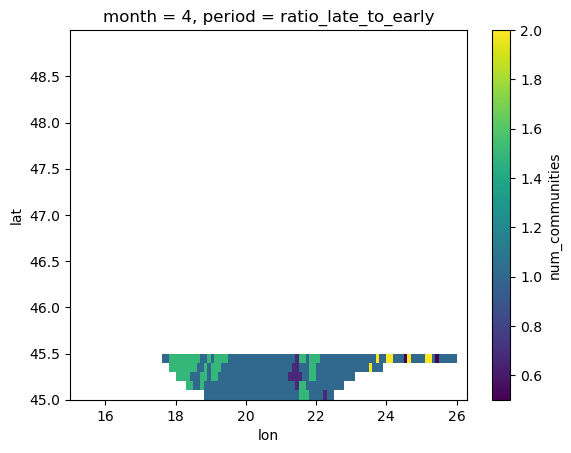

In [20]:
import xarray as xr
ds = xr.open_dataset(f"networks_indexes_{start_lat}_{end_lat}_output.nc")

# Example: Plot Shannon Entropy for Month 1, Early Period
ds['num_communities'].sel(month=4, period='ratio_late_to_early').plot()

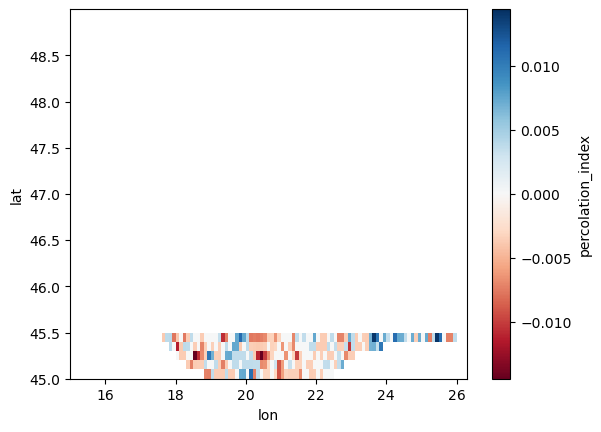

In [21]:
ds['percolation_index'].plot(cmap = 'RdBu')

In [27]:
import xarray as xr
import glob
import os

# Get all the partial output files
nc_files = glob.glob('networks_indexes_*_output.nc')
nc_files = [f for f in nc_files if 'combined' not in f]
print(f"Found {len(nc_files)} files to combine: {nc_files}")

if nc_files:
    # Open all datasets
    datasets = [xr.open_dataset(f) for f in nc_files]
    
    # Since all datasets have the same coordinates but different NaN regions,
    # we can use combine_first to merge them together.
    combined_ds = datasets[0]
    for ds in datasets[1:]:
        combined_ds = combined_ds.combine_first(ds)
        
    # Save the combined dataset
    output_filename = 'networks_indexes_combined_output.nc'
    combined_ds.to_netcdf(output_filename)
    print(f"Successfully combined and saved to {output_filename}!")
else:
    print("No files found to combine.")

Found 8 files to combine: ['networks_indexes_45.5_45.0_output.nc', 'networks_indexes_48.5_48.0_output.nc', 'networks_indexes_46.0_45.5_output.nc', 'networks_indexes_47.5_47.0_output.nc', 'networks_indexes_47.0_46.5_output.nc', 'networks_indexes_46.5_46.0_output.nc', 'networks_indexes_49_48.5_output.nc', 'networks_indexes_48.0_47.5_output.nc']
Successfully combined and saved to networks_indexes_combined_output.nc!


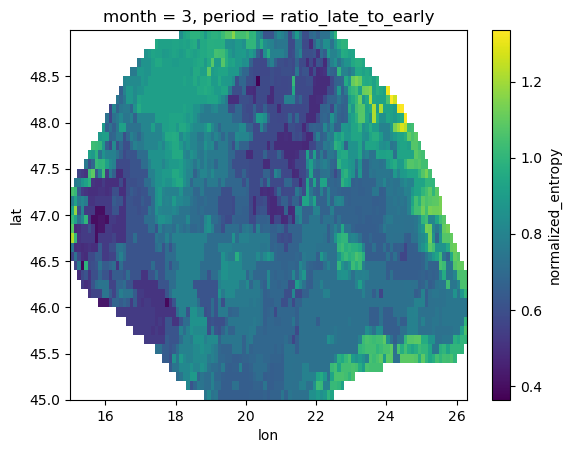

In [28]:
import xarray as xr
ds = xr.open_dataset(f"networks_indexes_combined_output.nc")

# Example: Plot Shannon Entropy for Month 1, Early Period
ds['normalized_entropy'].sel(month=3, period='ratio_late_to_early').plot()

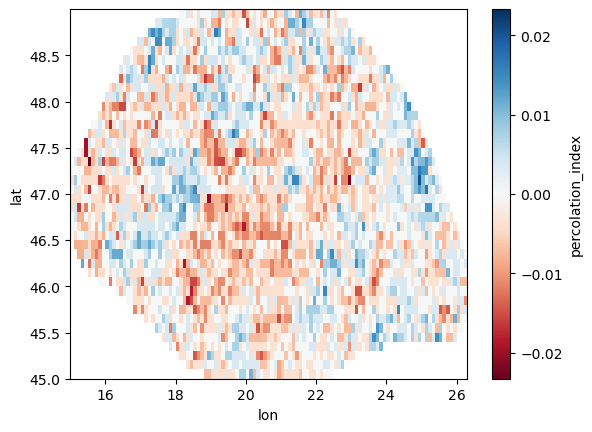

In [29]:
ds['percolation_index'].plot(cmap = 'RdBu')

In [30]:
ds

<xarray.Dataset> Size: 8MB
Dimensions:                          (lat: 40, lon: 113, month: 12, period: 3)
Coordinates:
  * lat                              (lat) float64 320B 48.95 48.85 ... 45.05
  * lon                              (lon) float64 904B 15.05 15.15 ... 26.25
  * month                            (month) int64 96B 1 2 3 4 5 ... 9 10 11 12
  * period                           (period) <U19 228B 'early' ... 'ratio_la...
Data variables:
    percolation_index                (lat, lon) float64 36kB ...
    num_communities                  (lat, lon, month, period) float64 1MB ...
    shannon_entropy                  (lat, lon, month, period) float64 1MB ...
    normalized_entropy               (lat, lon, month, period) float64 1MB ...
    simpson_index                    (lat, lon, month, period) float64 1MB ...
    unweighted_degree_fragmentation  (lat, lon, month, period) float64 1MB ...
    weighted_degree_fragmentation    (lat, lon, month, period) float64 1MB ...
Attributes:
    description:  Network indexes calculated across geographic grid

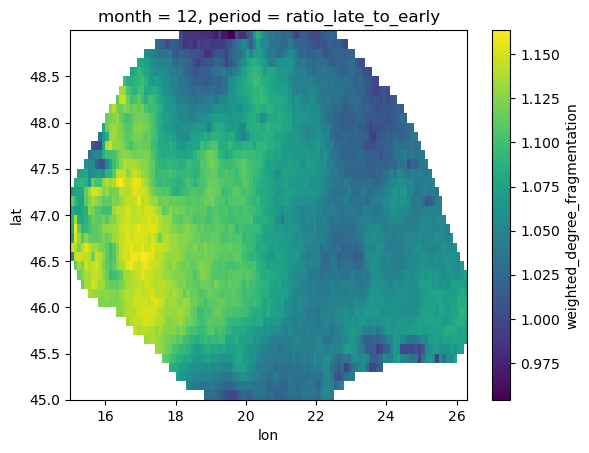

In [31]:
ds['weighted_degree_fragmentation'].sel(month=12, period='ratio_late_to_early').plot()